In [1]:
!uv pip install "pydantic[email]"

Using Python 3.12.11 environment at: /Users/macbookpro/Projects/agents/.venv
Checked 1 package in 2ms


In [2]:
from dotenv import load_dotenv
from pydantic import BaseModel, Field, EmailStr
from enum import Enum
from typing import List, NotRequired, Optional, TypedDict, Annotated, Any
from langgraph.graph.message import add_messages
import nest_asyncio
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
import gradio as gr
import uuid
from langchain_community.tools import WikipediaQueryRun, GoogleSerperRun
from langchain_community.utilities import WikipediaAPIWrapper, GoogleSerperAPIWrapper
import os
import requests
import resend
from langgraph.prebuilt import ToolNode

In [3]:
load_dotenv(override=True)

True

In [4]:
# Define enums

class SourceType(str, Enum):
  WEB = "web"
  WIKIPEDIA = "wikipedia"

In [5]:
# Define models

class ClarifierOutput(BaseModel):
  message: str = Field(..., description="The response message from the clarifier LLM")
  info_complete: bool = Field(..., description="Whether or not the user has provided enough information")
  email: Optional[str] = Field(..., description="The email address of the user")

class ValidationResult(BaseModel):
  location: Optional[str]
  intent: Optional[str]
  missing_fields: List[str]
  is_valid: bool

class PlannerOutput(BaseModel):
  location: str = Field(..., description="The location of the trip")
  categories: List[str] = Field(..., description="The categories to get information on e.g attractions, food, culture, history, etc.")
  search_queries: List[str] = Field(..., description="The search queries to get information on the categories")

class WebItem(BaseModel):
  title: str = Field(..., description="The title of the web item")
  url: str = Field(..., description="The url of the web item")
  source: SourceType = Field(..., description="The source of the web item, web or wikipedia")
  content: str = Field(..., description="The content of the web item")

class WebResearchOutput(BaseModel):
  items: List[WebItem] = Field(..., description="The web items to get information on the categories")

class WikiLandmark(BaseModel):
  name: str = Field(..., description="The name of the landmark")
  description: str = Field(..., description="The description of the landmark")

class WikipediaOutput(BaseModel):
  summary: str = Field(..., description="The summary of the wikipedia page")
  history: Optional[str] = Field(..., description="The history of the landmark")
  landmarks: List[WikiLandmark] = Field(..., description="The landmarks to get information on the categories")

class NormalizedItem(BaseModel):
  content: str = Field(..., description="The content of the item")
  content_type: str = Field(..., description="The category of the content e.g attraction, food, culture, history, etc.")
  source: SourceType = Field(..., description="The source of the content, web or wikipedia")
  title: Optional[str] = Field(..., description="The title of the item")
  reference_url: Optional[str] = Field(..., description="The reference url of the item")
  relevance_score: float = Field(..., ge=0, le=1, description="The relevance score of the content")

class NormalizedOutput(BaseModel):
  items: List[NormalizedItem] = Field(..., description="The output of the Normalizer Agent")

class FactItem(BaseModel):
  fact: str = Field(..., description="The fact to be written in the report")
  type: str = Field(..., description="The type of the fact e.g attraction, food, culture, history, etc.")
  source: str = Field(..., description="The url to the source of the fact")
  confidence: str = Field(..., description="The confidence level of the fact e.g high, medium, low")

class FactFinderOutput(BaseModel):
  facts: List[FactItem] = Field(..., description="The facts to be written in the report")

class WriterOutput(BaseModel):
  title: str = Field(..., description="The title of the travel guide")
  content: str = Field(
      default="",
      description="Full travel guide body in Markdown. Both title and content are required from the model; if output hits token limits, content may be omitted.",
  )

In [6]:
class State(TypedDict):
  messages: Annotated[List[Any], add_messages]
  info_complete: bool
  validation: ValidationResult
  planner: PlannerOutput
  web: WebResearchOutput
  web_raw: str
  wiki: WikipediaOutput
  wiki_raw: str
  normalized: NormalizedOutput
  facts: FactFinderOutput
  email: str
  report: WriterOutput

In [7]:
import asyncio
import sys

nest_asyncio.apply()
# # Uvicorn uses asyncio.run(..., loop_factory=...) on 3.12; nest_asyncio's replacement does not accept loop_factory.
# # Cache nest_asyncio's run once so re-running this cell does not capture our own wrapper.
# if not hasattr(asyncio, "_nest_asyncio_run_impl"):
#     asyncio._nest_asyncio_run_impl = asyncio.run


# def _asyncio_run_compat(main, *, debug=None, loop_factory=None, **kwargs):
#     impl = asyncio._nest_asyncio_run_impl
#     if debug is not None:
#         return impl(main, debug=debug)
#     return impl(main)


# asyncio.run = _asyncio_run_compat
# # uvicorn.server binds asyncio_run at import time; it may still point at nest_asyncio's run unless we rebind.
# for _name in ("uvicorn._compat", "uvicorn.server"):
#     _mod = sys.modules.get(_name)
#     if _mod is not None and hasattr(_mod, "asyncio_run"):
#         _mod.asyncio_run = asyncio.run

async_browser = create_async_playwright_browser(headless=False)  # headful mode
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [8]:
clarifier_llm = ChatOpenAI(model="gpt-4.1-nano")
clarifier_llm_with_output = clarifier_llm.with_structured_output(ClarifierOutput)

def clarifier(state: State) -> dict:
  system_message = """
  You are a helpful assistant that is speaking with a user interested in travelling somewhere. You need to ensure that the user has provided enough information to start destination research.
  The user's query MUST contain the location they want to visit.
  If the user has not provided the location, ask them for it.
  Also, you can optionally ask for the user's interests, otherwise you can come up with a list of interests based on the location.

  You must also ask for the user's email address.

  If the user has provided enough information, set info_complete to True; otherwise False. Put your user-facing reply in message.
  """

  messages = [SystemMessage(content=system_message)] + state["messages"]
  result = clarifier_llm_with_output.invoke(messages)

  return {
    "messages": [AIMessage(content=result.message)],
    "info_complete": result.info_complete,
    "email": result.email
  }

In [9]:
def format_conversation(messages: List[Any]) -> str:
    conversation = "Conversation history:\n\n"
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation += f"User: {message.content}\n"
        elif isinstance(message, AIMessage):
            text = message.content or "[Tools use]"
            conversation += f"Assistant: {text}\n"
    return conversation

In [10]:
planner_llm = ChatAnthropic(model="claude-sonnet-4-6")
planner_llm_with_output = planner_llm.with_structured_output(PlannerOutput)

def planner(state: State) -> dict:
  system_message = """
  You are an experienced travel agent. From the conversation, extract a structured trip request.
  `location` must be a real place the user wants to visit—never placeholders like UNKNOWN or unspecified.
  `categories` should reflect what they care about.
  `search_queries` should be specific to the destination when it is known; otherwise keep them aligned with what the user asked.
  """

  user_message = f"""
  Please extract the structured trip request from the conversation below:

  {format_conversation(state["messages"])}
  """

  convo = [SystemMessage(content=system_message)] + state["messages"] + [HumanMessage(content=user_message)]
  plan = planner_llm_with_output.invoke(convo)

  return {
      "planner": plan
  }

In [11]:
def clarifier_router(state: State) -> str:
  if state["info_complete"] == True:
    return "planner"
  else:
    return "END"

In [12]:
serper = GoogleSerperAPIWrapper()
serper_tool = GoogleSerperRun(api_wrapper=serper)

web_research_tools = [*tools, serper_tool]
WEB_TOOL_NAMES = frozenset(tool.name for tool in web_research_tools)


def _tool_call_name(tool_call) -> str | None:
  if isinstance(tool_call, dict):
    return tool_call.get("name")
  return getattr(tool_call, "name", None)


def _tool_call_id(tool_call) -> str | None:
  if isinstance(tool_call, dict):
    return tool_call.get("id")
  return getattr(tool_call, "id", None)


def filter_messages_for_tool_branch(messages: list, allowed_tool_names: frozenset) -> list:
  """Keep shared chat + tool rounds for this branch only.

  OpenAI requires every assistant ``tool_calls`` entry to be followed by matching
  ``ToolMessage``s (by ``tool_call_id``). We never drop tool replies for an
  assistant we keep. Other-branch tool rounds are skipped in full (assistant +
  its tool replies), which needs ordered messages — run wiki after web_normalizer.
  """
  filtered_messages = []
  index = 0
  messages_length = len(messages)
  while index < messages_length:
    message = messages[index]
    if isinstance(message, AIMessage) and message.tool_calls:
      call_names = {name for name in (_tool_call_name(tool_call) for tool_call in message.tool_calls) if name}
      if call_names <= allowed_tool_names:
        filtered_messages.append(message)
        index += 1
        # Include every consecutive tool result for this assistant (do not filter by name).
        while index < messages_length and isinstance(messages[index], ToolMessage):
          filtered_messages.append(messages[index])
          index += 1
      else:
        skip_ids = {tool_call_id for tool_call_id in (_tool_call_id(tool_call) for tool_call in message.tool_calls) if tool_call_id}
        index += 1
        seen = set()
        while skip_ids and index < messages_length and isinstance(messages[index], ToolMessage):
          tool_id = messages[index].tool_call_id
          if tool_id not in skip_ids:
            break
          seen.add(tool_id)
          index += 1
          if seen == skip_ids:
            break
      continue
    if isinstance(message, ToolMessage):
      index += 1
      continue
    filtered_messages.append(message)
    index += 1
  return filtered_messages


web_research_llm = ChatOpenAI(model="gpt-4.1-nano")
web_research_llm_with_tools = web_research_llm.bind_tools(web_research_tools)
web_research_llm_with_output = web_research_llm.with_structured_output(WebResearchOutput)

def web_researcher(state: State) -> dict:
  system_message = """
  You are a skilled web researcher with tools to search the web. You are given a list of search queries on a travel destination and you need to find the most relevant information on the web using all the tools at your disposal. You must use both the Playwright and Serper tools to find the most relevant information.

  You must find enough information on the destination which would be used to create a comprehensive travel guide.

  You must find information on the mentioned categories:

  Your output should be a list of web items with the following format:
  [
    {
      "title": "Title of the web item",
      "url": "URL of the web item",
      "source": "Source of the web item",
      "content": "Content of the web item"
    }
  ]

  You must return the output in the given format.
  """

  user_message = f"""
  Please find the most relevant information on the web for the following destination and categories:

  Destination: {state["planner"].location}
  Categories: {state["planner"].categories}

  Here are the search queries:
  {state["planner"].search_queries}
  """

  prior = filter_messages_for_tool_branch(state["messages"], WEB_TOOL_NAMES)
  system_msg = SystemMessage(content=system_message)
  task_msg = HumanMessage(content=user_message)
  # Tool loop: do not append another Human after ToolMessage (breaks tool → assistant ordering).
  if prior and isinstance(prior[-1], ToolMessage):
    messages = [system_msg] + prior
    response = web_research_llm_with_tools.invoke(messages)
    return {"messages": [response]}
  messages = [system_msg] + prior + [task_msg]
  response = web_research_llm_with_tools.invoke(messages)
  return {"messages": [task_msg, response]}

def web_normalizer(state: State) -> dict:
  system_message = """
  You are a skilled assistant. You need to extract the most relevant information from the web items and return it in a structured format.
  """

  web_raw = (state.get("web_raw") or "").strip()
  if not web_raw:
    web_raw = "\n\n".join(
        str(m.content)
        for m in state["messages"]
        if isinstance(m, ToolMessage) and m.name in WEB_TOOL_NAMES
    )

  user_message = f"""
  Please normalize the following web items:

  {web_raw}
  """

  messages = [SystemMessage(content=system_message)] + state["messages"] + [HumanMessage(content=user_message)]
  result = web_research_llm_with_output.invoke(messages)

  return {
    "web": result
  }

In [13]:
wikipedia = WikipediaAPIWrapper()
wiki_tool = WikipediaQueryRun(api_wrapper=wikipedia)
WIKI_TOOL_NAMES = frozenset({wiki_tool.name})

wiki_research_llm = ChatOpenAI(model="gpt-4.1-mini")
wiki_research_llm_with_tools = wiki_research_llm.bind_tools([wiki_tool])
wiki_research_llm_with_output = wiki_research_llm.with_structured_output(WikipediaOutput)

def wiki_researcher(state: State) -> dict:
  system_message = """
  You are a skilled wikipedia researcher with tools to search Wikipedia. You are given a list of search queries on a travel destination and you need to find the most relevant information on Wikipedia using all the tools at your disposal.

  You must find enough information on the destination which would be used to create a comprehensive travel guide.

  You must find information on the mentioned categories:

  Your output must include a summary of the wikipedia page, history of the destination, and a list of landmarks most relevant to the categories.
  """

  user_message = f"""
  Please find the most relevant information on Wikipedia for the following destination and categories:

  Destination: {state["planner"].location}
  Categories: {state["planner"].categories}

  Here are the search queries:
  {state["planner"].search_queries}
  """

  prior = filter_messages_for_tool_branch(state["messages"], WIKI_TOOL_NAMES)
  system_msg = SystemMessage(content=system_message)
  task_msg = HumanMessage(content=user_message)
  if prior and isinstance(prior[-1], ToolMessage):
    messages = [system_msg] + prior
    result = wiki_research_llm_with_tools.invoke(messages)
    return {"messages": [result]}
  messages = [system_msg] + prior + [task_msg]
  result = wiki_research_llm_with_tools.invoke(messages)
  return {"messages": [task_msg, result]}

def wiki_normalizer(state: State) -> dict:
  system_message = """
  You are a skilled assistant. You need to extract the most relevant information from the wikipedia page and return it in a structured format.
  """

  wiki_raw = (state.get("wiki_raw") or "").strip()
  if not wiki_raw:
    wiki_raw = "\n\n".join(
        str(m.content)
        for m in state["messages"]
        if isinstance(m, ToolMessage) and m.name in WIKI_TOOL_NAMES
    )

  user_message = f"""
  Please normalize the following wikipedia page:

  {wiki_raw}
  """

  messages = [SystemMessage(content=system_message)] + state["messages"] + [HumanMessage(content=user_message)]
  result = wiki_research_llm_with_output.invoke(messages)

  return {
    "wiki": result
  }


In [14]:
aggregator_llm = ChatOpenAI(model="gpt-4.1-mini")
aggregator_llm_with_output = aggregator_llm.with_structured_output(NormalizedOutput)

def aggregator(state: State) -> dict:
  system_message = """
  You are a skilled aggregator. You need to aggregate the web items and wikipedia page and return them in a structured format. You also need to remove any duplicate information, assign relevance scores to each item to rank them based on relevance.
  """

  user_message = f"""
  Please aggregate the following web items and wikipedia page:

  Web Items: {state["web"]}
  Wikipedia Page: {state["wiki"]}
  """

  messages = [SystemMessage(content=system_message)] + state["messages"] + [HumanMessage(content=user_message)]
  result = aggregator_llm_with_output.invoke(messages)

  return {
    "normalized": result
  }

In [15]:
fact_finder_llm = ChatAnthropic(model="claude-sonnet-4-6", max_tokens=8192)
fact_finder_llm_with_output = fact_finder_llm.with_structured_output(FactFinderOutput)

def fact_finder(state: State) -> dict:
  system_message = """
  You are a Fact Extraction Engine.

  Your task is to extract ONLY verifiable, atomic facts from the provided sources.

  ---

  ## Rules

  1. Extract facts EXACTLY as supported by the source.
  2. Do NOT infer, generalize, or combine multiple facts.
  3. Do NOT introduce new numbers, rankings, or claims.
  4. If a statement is uncertain, vague, or comparative (e.g., "one of the best"), either:

    - rewrite it into a neutral factual statement, OR
    - discard it if it cannot be made precise.
  5. Each fact must be independently understandable (no context required).
  6. Preserve numerical precision exactly as stated.
  7. Do NOT include opinions, marketing language, or descriptive fluff.

  ---

  ## Fact Types to Extract

  - Population statistics
  - Dates and historical events
  - Geographic information
  - Infrastructure details (transport, buildings, systems)
  - Verified rankings or awards (ONLY if explicitly stated)
  - Counts (e.g., number of museums, stations, airports)
  - Institutional presence (e.g., headquarters, organizations)

  ---

  ## Output Format (STRICT JSON)

  {
  "facts": [
  {
  "fact": "<clear, atomic statement>",
  "type": "<one of: population | history | geography | infrastructure | culture | ranking | other>",
  "source": "<short source reference or title>",
  "confidence": "high | medium | low"
  }
  ]
  }

  ---

  ## Additional Constraints

  - Maximum 1 fact per entry
  - No duplicate facts
  - No combined sentences
  - No superlatives unless explicitly verified (e.g., "largest in the world" must be directly stated in source)
  - If unsure, mark confidence as "low" or discard

  ---

  ## Output

  Return ONLY the JSON object. No explanation.

  ## Edge Case

  If NO facts meet the criteria, return:
  {
    "facts": []
  }

  NEVER return an empty object {}. Always include the "facts" key.
  """

  user_message = f"""
  ## Input

  {state["normalized"]}
  """

  messages = [SystemMessage(content=system_message)] + state["messages"] + [HumanMessage(content=user_message)]
  result = fact_finder_llm_with_output.invoke(messages)

  return {
    "facts": result
  }

In [ ]:
# Default max_tokens=1024 truncates structured output (title only → ValidationError on WriterOutput.content).
writer_llm = ChatAnthropic(model="claude-sonnet-4-6", max_tokens=8192)
writer_llm_with_output = writer_llm.with_structured_output(WriterOutput)

def writer(state: State) -> dict:
  system_message = f"""
  You are a skilled travel guide writer. You need to write a comprehensive travel guide based on the aggregated web items and wikipedia page items. You must include all the information from the web items and wikipedia page items in the travel guide. Also remember to arrange the information based on the relevance scores.

  Your report must be catchy and engaging. Write an interesting catchy title and properly structure the content in Markdown format.

  Your report must mention:
  - A summary of the destination
  - Historical information about the destination
  - Recommend the best places to visit based on the categories
  - Recommend the best food to eat based on the categories
  - Recommend the best activities to do based on the categories
  - Recommend the best hotels to stay in based on the categories
  - Recommend the best transport to use based on the categories
  - Recommend the best things to buy based on the categories
  - Recommend the best things to buy based on the categories

  Also, you must mention some fun facts about the destination.

  Write this report in an engaging and persuasive tone.

  However:
  - Do NOT introduce new facts
  - Do NOT exaggerate claims
  - Use phrases like "one of the", "among the most" unless explicitly verified
  - Maintain factual accuracy over persuasion

  Use ONLY the provided sources.

  When describing rankings, awards, or global comparisons:
  - Only state them if explicitly supported by these provided facts: {state["facts"]}
  - Otherwise, use neutral descriptive language instead of superlatives

  For any claim:
  - If explicitly supported → state confidently
  - If partially supported → hedge language
  - If not supported → do NOT include

  Avoid absolute claims like:
  "the best", "the most", "the largest"
  unless explicitly verified.

  For every factual statement:
  - It must correspond to a provided fact
  - Do not introduce new numbers, rankings, or superlatives
  - If unsure, soften the claim (e.g., "one of the largest" instead of "the largest")
  """

  user_message = f"""
  Please write a comprehensive travel guide based on the following items:

  {state["normalized"]}
  """

  convo = [SystemMessage(content=system_message)] + state["messages"] + [HumanMessage(content=user_message)]
  report = writer_llm_with_output.invoke(convo)
  body = (report.content or "").strip()
  if not body:
    body = (
        "_The guide body was cut off by the output limit. Try fewer categories, a shorter briefing, or run the writer again._"
    )

  return {
    "messages": [AIMessage(content=f"{report.title}\n\n{body}")],
    "report": report,
  }

In [30]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"


@tool
def send_push_notification(text: str) -> str:
  """Send a short push notification to the user via Pushover (title of report or summary)."""
  if not pushover_token or not pushover_user:
    return "Pushover not configured (set PUSHOVER_TOKEN and PUSHOVER_USER)."
  r = requests.post(
      pushover_url,
      data={"token": pushover_token, "user": pushover_user, "message": text},
      timeout=30,
  )
  return f"pushover_status={r.status_code}"


@tool
def send_travel_email(recipient_email: str, subject: str, html_body: str) -> str:
  """Send the travel report email via Resend. Use recipient_email, subject, and html_body as separate arguments."""
  from_email = "onboarding@resend.dev"

  resend.api_key = os.getenv("RESEND_API_KEY")

  params: resend.Emails.SendParams = {
      "from": f"Travel Agent <{from_email}>",
      "to": [recipient_email],
      "subject": subject,
      "html": html_body,
  }

  resend.Emails.send(params)
  return "email_sent"


# Structured tools (not legacy ``Tool``) so bind_tools / ToolNode pass named JSON args correctly.
report_tools = [send_push_notification, send_travel_email]
REPORT_TOOL_NAMES = frozenset(tool.name for tool in report_tools)

report_llm = ChatOpenAI(model="gpt-4.1-nano", max_completion_tokens=8192)
report_llm_with_tools = report_llm.bind_tools(report_tools)

def report_sender(state: State) -> dict:
  system_message = """
  You are a helpful email specialist agent specializing in delivering reports to users.

  You will be provided with a WriterOutput object containing a title and markdown content.

  Your task:
  1. Extract the user's email address from the user prompt
  2. Convert the markdown content to well-formatted professional HTML
  3. Call send_push_notification with the report title (or short summary) in the text argument
  4. Call send_travel_email once with recipient_email, subject (report title), and html_body (full HTML body)

  Execute immediately with the data provided.

  Make sure you send the push notification and email immediately.
  """

  user_message = f"""
  Please send the report to this email: {state["email"]}.

  Report Title: {state["report"].title}
  Report Content: {state["report"].content}
  """

  prior = filter_messages_for_tool_branch(state["messages"], REPORT_TOOL_NAMES)
  system_msg = SystemMessage(content=system_message)
  task_msg = HumanMessage(content=user_message)
  if prior and isinstance(prior[-1], ToolMessage):
    messages = [system_msg] + prior
    result = report_llm_with_tools.invoke(messages)
    return {"messages": [result]}
  messages = [system_msg] + prior + [task_msg]
  result = report_llm_with_tools.invoke(messages)

  return {
    "messages": [task_msg, result],
  }


In [18]:
def web_researcher_router(state: State) -> str:
  last_message = state["messages"][-1]

  if isinstance(last_message, AIMessage) and last_message.tool_calls:
    return "tools"
  else:
    return "web_normalizer"

def wiki_researcher_router(state: State) -> str:
  last_message = state["messages"][-1]

  if isinstance(last_message, AIMessage) and last_message.tool_calls:
    return "tools"
  else:
    return "wiki_normalizer"

def report_router(state: State) -> str:
  last_message = state["messages"][-1]

  if isinstance(last_message, AIMessage) and last_message.tool_calls:
    return "tools"
  else:
    return "END"

In [31]:
graph_builder = StateGraph(State)

graph_builder.add_node("clarifier", clarifier)
graph_builder.add_node("planner", planner)
graph_builder.add_node("web_researcher", web_researcher)
graph_builder.add_node("web_search_tools", ToolNode(tools=web_research_tools))
graph_builder.add_node("wiki_researcher", wiki_researcher)
graph_builder.add_node("wiki_search_tools", ToolNode(tools=[wiki_tool]))
graph_builder.add_node("web_normalizer", web_normalizer)
graph_builder.add_node("wiki_normalizer", wiki_normalizer)
graph_builder.add_node("aggregator", aggregator)
graph_builder.add_node("fact_finder", fact_finder)
graph_builder.add_node("writer", writer)
graph_builder.add_node("report_sender", report_sender)
graph_builder.add_node("report_tools", ToolNode(tools=report_tools))

graph_builder.add_edge(START, "clarifier")
graph_builder.add_conditional_edges("clarifier", clarifier_router, {"planner": "planner", "END": END})
graph_builder.add_edge("planner", "web_researcher")
# Wiki after web so shared ``messages`` stays one ordered tool thread (parallel web+wiki interleaves tool replies and breaks OpenAI validation).
graph_builder.add_edge("web_normalizer", "wiki_researcher")
graph_builder.add_conditional_edges("web_researcher", web_researcher_router, {"tools": "web_search_tools", "web_normalizer": "web_normalizer"})
graph_builder.add_edge("web_search_tools", "web_researcher")
graph_builder.add_conditional_edges("wiki_researcher", wiki_researcher_router, {"tools": "wiki_search_tools", "wiki_normalizer": "wiki_normalizer"})
graph_builder.add_edge("wiki_search_tools", "wiki_researcher")
graph_builder.add_edge("wiki_normalizer", "aggregator")
graph_builder.add_edge("aggregator", "fact_finder")
graph_builder.add_edge("fact_finder", "writer")
graph_builder.add_edge("writer", "report_sender")
graph_builder.add_conditional_edges("report_sender", report_router, {"tools": "report_tools", "END": END})
graph_builder.add_edge("report_tools", "report_sender")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

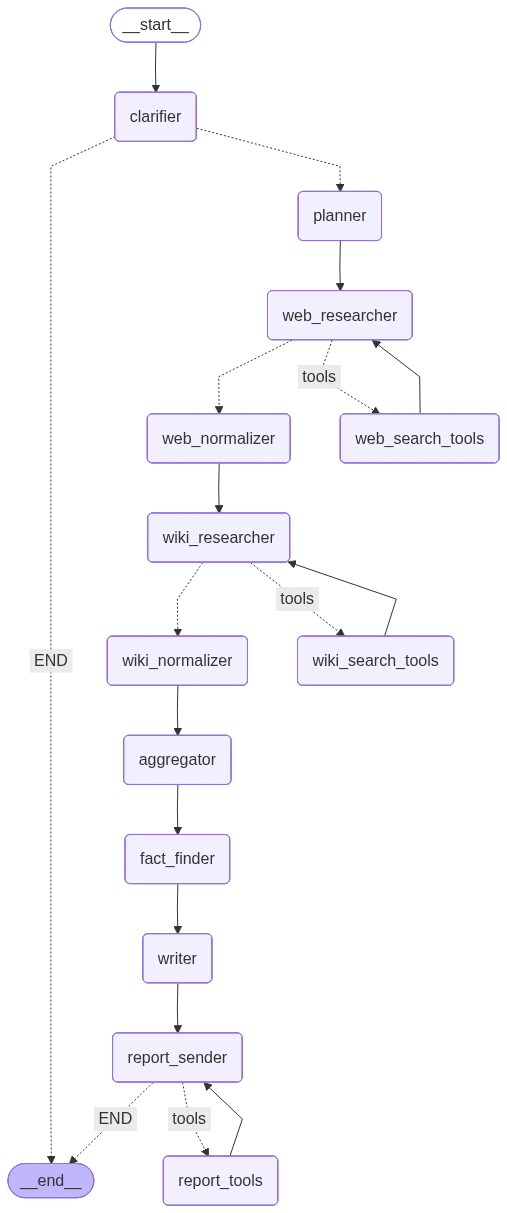

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
def format_message(message: Any) -> dict:
  role = {"human": "user", "ai": "assistant", "system": "system"}.get(message.type, "assistant")
  content = message.content
  return {"role": role, "content": content}

def make_thread_id() -> str:
    return str(uuid.uuid4())

async def process_message(message, history, thread):
  try:
    config = {"configurable": {"thread_id": thread}}
    history = history or []
    yield [*history, {"role": "user", "content": message}], "", thread
    state = {"messages": [HumanMessage(content=message)]}
    result = await graph.ainvoke(state, config=config)
    turn = [format_message(message) for message in result["messages"]]
    yield turn, "", thread
  except Exception as e:
    print(f"Chat error: {e}", flush=True)
    yield [*history, {"role": "user", "content": message}, {"role": "assistant", "content": "⚠️ Something went wrong. Please try again or start a new conversation."}], "", thread

In [32]:
with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as ui:
  gr.Markdown("## Travel Agent")
  thread = gr.State(make_thread_id())
  with gr.Row():
    with gr.Column():
      chatbot = gr.Chatbot(label="Travel Agent", height=300, type="messages")
      message = gr.Textbox(show_label=False, placeholder="Your request to your travel agent")
      send_btn = gr.Button("Submit")

  send_btn.click(process_message, [message, chatbot, thread], [chatbot, message, thread])
  message.submit(process_message, [message, chatbot, thread], [chatbot, message, thread])

ui.launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
